In [2]:
# dependency libararies
import warnings
import os
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import gc

# sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC

# treeple functions
import treeple
from treeple.ensemble import HonestForestClassifier, ObliqueRandomForestClassifier
from treeple.tree import ObliqueDecisionTreeClassifier
from treeple.stats import build_oob_forest

from gaussian_mix import *

warnings.filterwarnings("ignore")


# default list for the results
from collections import defaultdict

In [3]:
# for each row calculate the mi
filename = "./Fig_1_1.json"
df = pd.read_json(filename)
MI = []
y_pred_probas = []
for i in range(len(df)):
    row = df.iloc[i]
    posterior = np.array(row["posterior"])
    y_pred_proba = np.array(row['posterior'])[:,1][0]
    y_pred_probas.append(y_pred_proba)
    n = posterior.shape[0]
    # generate the y_true
    y_true = [0] * (n//2) + [1] * (n//2)
    # get the mi
    mi = Calculate_MI(y_true, posterior)
    MI.append(mi)
df["MI"] = MI
df["y_pred_proba"] = y_pred_probas
df

,model,method,dim,n,fit_time,accuracy,auc,f1,precision,recall,mi,posterior,MI,y_pred_proba
0,HonestForestClassifier,HonestForest,2,1000,16.871548,0.5,0.5,0.666667,0.5,1,0.042229,"[[0.355724685638649, 0.6442753143613501], [0.3...",-0.245930,0.644275
1,RandomForestClassifier,isotonic,2,1000,34.124818,0.5,0.5,0.666667,0.5,1,0.146532,"[[0.23616168689698103, 0.7638383131030191], [0...",-0.095452,0.763838
2,RandomForestClassifier,sigmoid,2,1000,5.173483,0.5,0.5,0.666667,0.5,1,0.233440,"[[0.17242293043013202, 0.8275770695698671], [0...",0.029930,0.827577
3,LogisticRegression,isotonic,2,1000,0.712686,0.5,0.5,0.666667,0.5,1,0.004707,"[[0.45152337858220204, 0.5484766214177971], [0...",-0.300062,0.548477
4,LogisticRegression,sigmoid,2,1000,0.721819,0.5,0.5,0.666667,0.5,1,0.005436,"[[0.447914847038041, 0.552085152961958], [0.44...",-0.299011,0.552085
5,SVC,isotonic,2,1000,0.682096,0.5,0.5,0.666667,0.5,1,0.007261,"[[0.439818076660181, 0.5601819233398181], [0.4...",-0.296377,0.560182
6,SVC,sigmoid,2,1000,0.787823,0.5,0.5,0.666667,0.5,1,0.017219,"[[0.407480301823603, 0.592519698176396], [0.40...",-0.282011,0.592520
7,GradientBoostingClassifier,isotonic,2,1000,0.300315,0.5,0.5,0.666667,0.5,1,0.070002,"[[0.31513202661223805, 0.6848679733877621], [0...",-0.205862,0.684868
8,GradientBoostingClassifier,sigmoid,2,1000,1.639122,0.5,0.5,0.666667,0.5,1,0.151323,"[[0.23211876174393603, 0.767881238256063], [0....",-0.088539,0.767881
9,HonestForestClassifier,HonestForest,2,1000,17.345730,0.5,0.5,0.666667,0.5,1,0.001679,"[[0.471036862175413, 0.528963137824586], [0.47...",-0.304431,0.528963


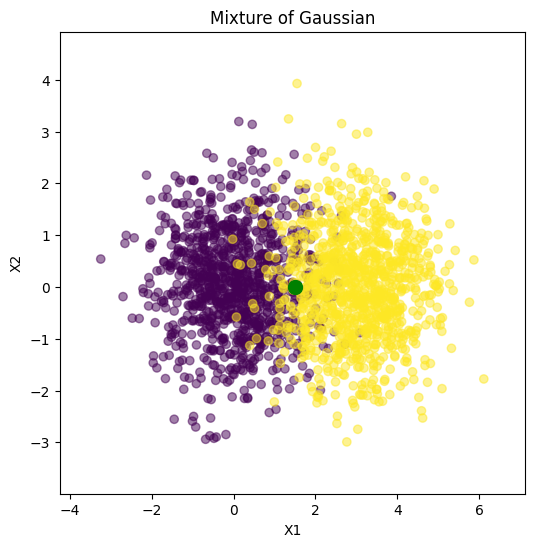

[[0.24508501 0.75491499]
 [0.24508501 0.75491499]]


In [42]:
def plot_gaussian_mixture(mu_class0, mu_class1_1, mu_class1_2, sig, n, dim_info, dim_total, mix, seed, axs=None):
    X, X_all, y = Mix_Gaussian(
        mu_class0, mu_class1_1, mu_class1_2, sig, n, dim_info, dim_total, mix, seed
    )
    # print(X.shape, X_all.shape, y.shape)

    # genetate a test dataset from the intersection of the two classes
    n_test = 100
    mu_class0 = [0]
    test_mu_class1_1 = [3 / 2, 0]
    test_mu_class1_2 = [3 / 2, 0]
    test_sig = 0.5
    X_test, X_test_all, y_test = Mix_Gaussian(
        mu_class0,
        test_mu_class1_1,
        test_mu_class1_2,
        test_sig,
        n_test,
        dim_info,
        dim_total,
        mix,
        seed,
    )
    # get only the sample with the label 1
    # test_X = test_X[test_y.flatten() == 1]
    # test_X_all = test_X_all[test_y.flatten() == 1]
    # test_y = test_y[test_y.flatten() == 1]
    X_test, y_test = [[3 / 2, 0], [3 / 2, 0]],[0, 1]
    X_noise = np.random.normal(0, 1, (2, dim_total - dim_info))
    X_test_all = np.hstack((X_test, X_noise))
    # print(test_X.shape, test_X_all.shape, test_y.shape)
    if axs is not None:
        axs.scatter(X_all[:, 0], X_all[:, 1], c=y.flatten(), alpha=0.5)
        # axs.scatter(test_X_all[:, 0], test_X_all[:, 1], c="green")
        axs.scatter(
            X_test[0][0],
            X_test[0][1],
            c="green",
            marker="o",
            s=100,
            label="Test Data",
            alpha=1,
        )
        axs.set_xlabel("X1")
        axs.set_ylabel("X2")
        axs.set_title("Mixture of Gaussian")
    else:
        # plot the test dataset on the same plot
        plt.figure(figsize=(6, 6))
        plt.scatter(X_all[:, 0], X_all[:, 1], c=y.flatten(), label="Train Data", alpha=0.5)
        plt.scatter(X_test[0][0], X_test[0][1], c="green", marker="o", s=100, label="Test Data", alpha=1)
        plt.xlim( min(X_all[:, 0]) -1 , max(X_all[:, 0])+1)
        plt.ylim( min(X_all[:, 1]) -1 , max(X_all[:, 1])+1)
        plt.xlabel("X1")
        plt.ylabel("X2")
        plt.title("Mixture of Gaussian")
        plt.show()
    posterior, tpr_s = Mix_Gaussian_Truth_Calculation(
        X_test_all, y_test, mu_class0, test_mu_class1_1, test_mu_class1_2, test_sig, dim_info, mix
    )
    y_pred = np.argmax(posterior, axis=1)
    mi_truth = Calculate_MI(y, posterior)
    return mi_truth, posterior, tpr_s
mu_class0 = [0]
mu_class1_1 = [3, 0]
mu_class1_2 = [3, 0]
sig = 1
test_mu_class0 = [0]
test_mu_class1_1 = [3/2, 0]
test_mu_class1_2 = [3/2, 0]
test_sig = 1
n = 1000
dim_info = 2
dim_total = 10
mix = [0.5, 0.5]
seed = 42
X_test, y_test = [[3 / 2, 0], [3 / 2, 0]],[0, 1]
X_noise = np.random.normal(0, 1, (2, dim_total - dim_info))
X_test_all = np.hstack((X_test, X_noise))
# X_test, X_test_all, y_test = Mix_Gaussian(
#     test_mu_class0, test_mu_class1_1, test_mu_class1_2, test_sig, n, dim_info, dim_total, mix, seed
# )
posterior, tpr_s = Mix_Gaussian_Truth_Calculation(
    X_test_all, y_test, test_mu_class0, test_mu_class1_1, test_mu_class1_2, test_sig, dim_info, mix
)
# y_pred = np.argmax(posterior, axis=1)
# mi_truth = Calculate_MI(y, posterior)
# print(mi_truth)
# print(posterior.shape, tpr_s.shape)
_, _, _= plot_gaussian_mixture(
    mu_class0,
    mu_class1_1,
    mu_class1_2,
    test_sig,
    n,
    dim_info,
    dim_total,
    mix,
    seed,
    axs=None,
)
print(posterior)

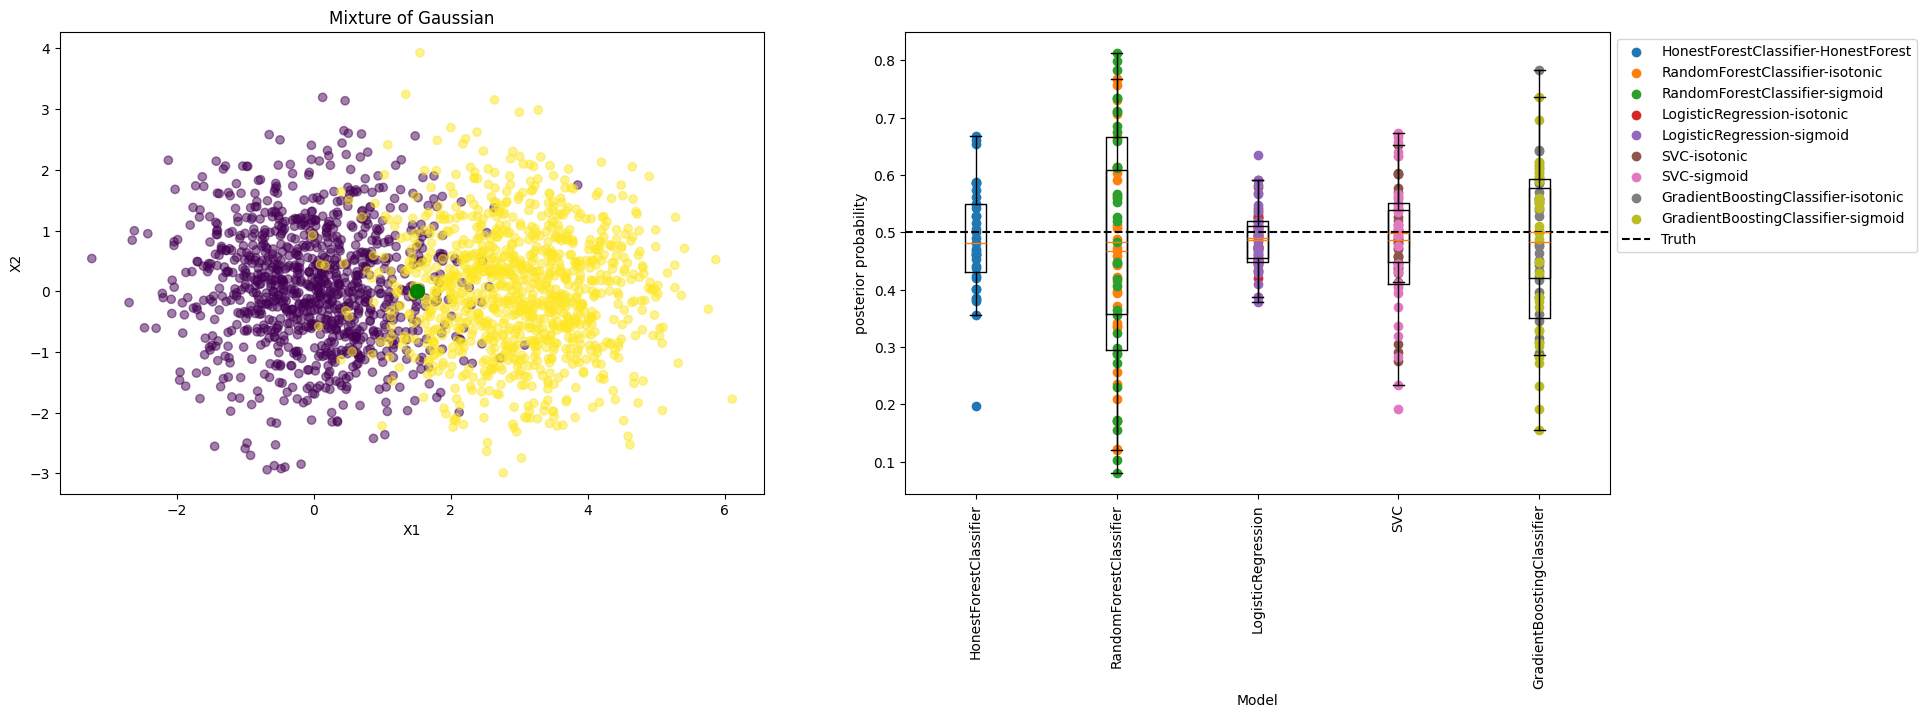

In [55]:
# for each row calculate the mi
filename = "./Fig_1_1.json"
df = pd.read_json(filename)
MI = []
y_pred_probas = []
for i in range(len(df)):
    row = df.iloc[i]
    posterior = np.array(row["posterior"])
    y_pred_proba = np.array(row["posterior"])[:, 0][1]
    y_pred_probas.append(y_pred_proba)
    n = posterior.shape[0]
    # generate the y_true
    y_true = [0] * (n // 2) + [1] * (n // 2)
    # get the mi
    mi = Calculate_MI(y_true, posterior)
    MI.append(mi)
df["MI"] = MI
df["y_pred_proba"] = y_pred_probas

# plot the y_pred_proba in boxplot with scatter for each model in x-axis
models = df["model"].unique()
methods = ["isotonic", "sigmoid"]
mu_class0 = [0]
mu_class1_1 = [3, 0]
mu_class1_2 = [3, 0]
n = 1000
dim_info = 2
dim_total = 10
mix = [0.5, 0.5]
test_sig = 1
seed = 42

fig, ax = plt.subplots(1, 2, figsize=(20, 6))
_, _, _ = plot_gaussian_mixture(
    mu_class0,
    mu_class1_1,
    mu_class1_2,
    test_sig,
    n,
    dim_info,
    dim_total,
    mix,
    seed,
    axs=ax[0],
)
for i, model in enumerate(models):
    if model == "HonestForestClassifier":
        method = "HonestForest"
        y_pred_proba = df[(df["model"] == model) & (df["method"] == method)][
            "y_pred_proba"
        ]
        ax[1].scatter([i] * len(y_pred_proba), y_pred_proba, label=f"{model}-{method}")
        ax[1].boxplot(y_pred_proba, positions=[i], showfliers=False)
    else:
        for j, method in enumerate(methods):
            y_pred_proba = df[(df["model"] == model) & (df["method"] == method)]["y_pred_proba"]
            ax[1].scatter([i] * len(y_pred_proba), y_pred_proba, label=f"{model}-{method}")
            ax[1].boxplot(y_pred_proba, positions=[i], showfliers=False)
# add a vline at y=0.5
ax[1].axhline(y=0.5, color="black", linestyle="--", label="Truth")
ax[1].set_xticks(range(len(models)))
ax[1].set_xticklabels(models, rotation=90)
ax[1].set_xlabel("Model")
ax[1].set_ylabel("posterior probability")
ax[1].legend()
# move the legend outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

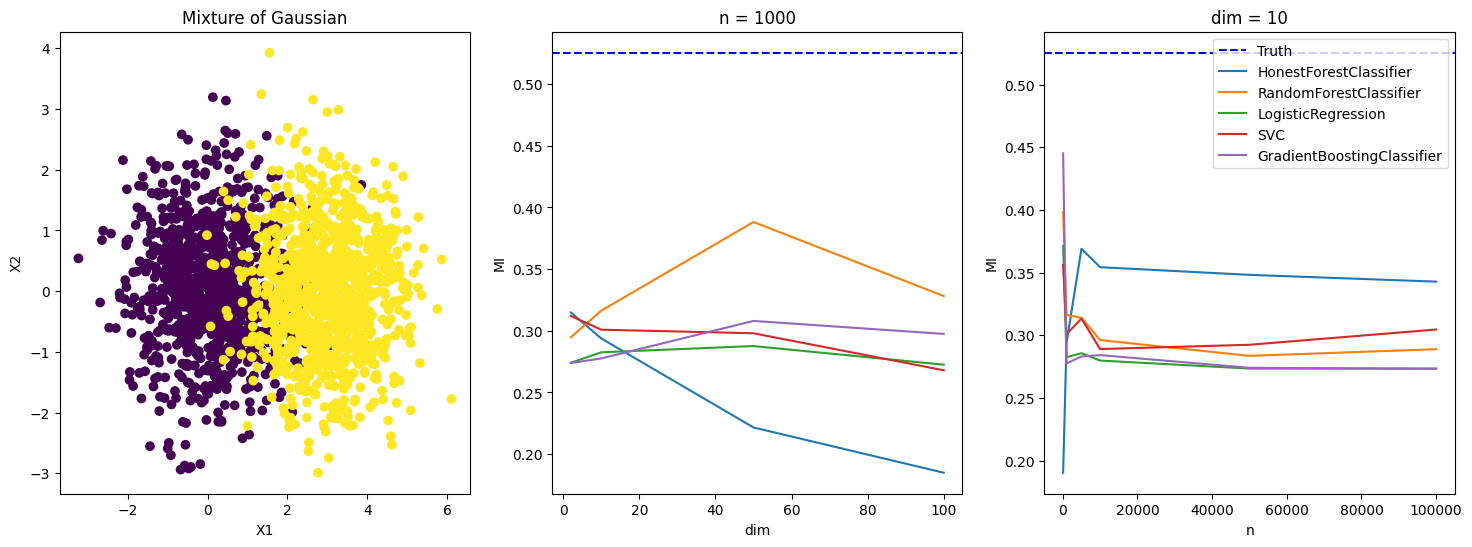

In [ ]:
# make a panel of 3 plots
n= N[0]
dim = dims[0]
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
mi_truth, posterior, tpr_s = plot_gaussian_mixture(
    mu_class0,
    mu_class1_1,
    mu_class1_2,
    sig,
    n,
    dim_info,
    dim_total,
    mix,
    seed,
    axs=axs[0],
)
axs[1].axhline(y=mi_truth, color="b", linestyle="--")
axs[2].axhline(y=mi_truth, color="b", linestyle="--", label="Truth")
for model in models:
    df_model = df[df["model"] == model]
    df_model = df_model[df_model["n"] == n]   
    posterior = np.array(df_model["posterior"].values[0])
    mean_posterior = np.mean(posterior[:,1], axis=0) 
    axs[1].plot(df_model["dim"], df_model["MI"], label=model)
    axs[1].set_ylabel("MI")
    axs[1].set_xlabel("dim")
    axs[1].set_title(f"n = {n}")
    df_model = df[df["model"] == model]
    df_model = df_model[df_model["dim"] == dim]
    posterior = np.array(df_model["posterior"].values[0])
    mean_posterior = np.mean(posterior[:,1], axis=0)
    axs[2].plot(df_model["n"], df_model["MI"], label=model)
    axs[2].set_ylabel("MI")
    axs[2].set_xlabel("n")
    axs[2].set_title(f"dim = {dim}")
axs[2].legend()
plt.show()